In [39]:
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt
import pickle
import sys, os
sys.path.append(os.path.abspath('..'))
import torch

from mounirood.tester import PonderationTester
from mounirood.datasets import get_y
from mounirood.framework import FrameworkFactory
from mounirood.modality_fusion import calc_perturbations, CoefficientPonderator
#from mounirood.eval_functions import auc_and_fpr_recall, visualize, calc_outputs_test, calc_correlations, separabilite
from sklearn import metrics

os.environ["CUDA_VISIBLE_DEVICES"] = "0,1"
torch.cuda.is_available()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


True

Failure prediction:
- Essayer de prédire si le modèle va se tromper ou pas.
- Uniquement sur données ID.
- Récupérer les confs, preds et labels
- Utiliser les méthodes (MSP direct, pondération perturbations, aggrégation max/min/mean etc., )

# Near OOD

## HMDB

In [ ]:
def failure_prediction(framework, dataset, layer_proc):
    
    #conf = framework.get_confs("id", layer_proc, dataset)
    pred = framework.get_preds("id", layer_proc, dataset)
    labels = framework.get_saved_files("label", "id", layer_proc, dataset)
    failure_gt_id = np.where(pred!=labels, 1, 0)
    pred = framework.get_preds("ood", layer_proc, dataset)
    labels = framework.get_saved_files("label", "ood", layer_proc, dataset)
    failure_gt_ood = np.where(pred!=labels, 1, 0)
    return failure_gt_id, failure_gt_ood

In [5]:
framework = FrameworkFactory("near_ood")
dataset = "HMDB"
layer_proc = "react"

In [21]:
failure_gt_id, failure_gt_ood = failure_prediction(framework, dataset, layer_proc)

(array([411.,   0.,   1.,   1.,  46.]),
 array([-0.5,  0.5,  1.5,  2.5,  3.5,  4.5]),
 <BarContainer object of 5 artists>)

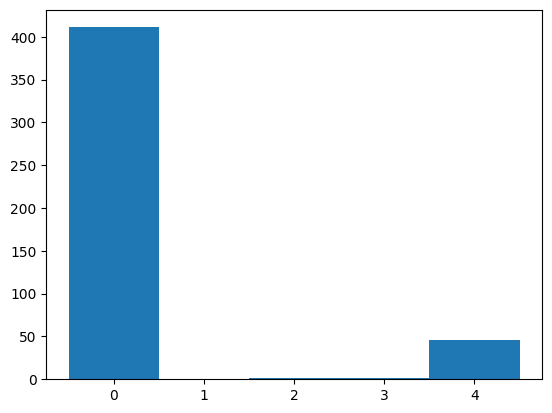

In [ ]:
plt.hist(failure_gt_id.sum(axis=1), bins=np.arange(failure_gt_id.shape[1]+2)-0.5)

En général quand ils se trompent ils se trompent tous en même temps

(array([   0.,    0.,    0.,    0., 3744.]),
 array([-0.5,  0.5,  1.5,  2.5,  3.5,  4.5]),
 <BarContainer object of 5 artists>)

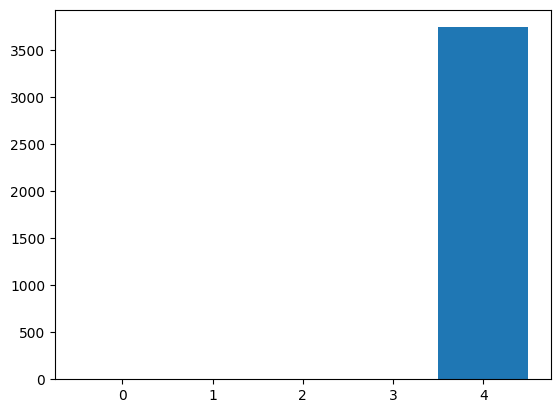

In [ ]:
plt.hist(failure_gt_ood.sum(axis=1), bins=np.arange(failure_gt_id.shape[1]+2)-0.5)

In [41]:
from mounirood.tests_integrite import test_all
test_all()

FileNotFoundError: [Errno 2] No such file or directory: 'HMDB-rgb-flow//saved_files/id_HMDB_conf_baseline_best_test.npy'

In [38]:
import os
os.path.exists("/data/maouche/MultiOOD/HMDB-rgb-flow/saved_files/id_HMDB_conf_baseline_best_test.npy")

True

In [32]:
framework = FrameworkFactory("near_ood")
dataset = "HMDB"
layer_proc = "react"

pred = framework.get_preds("id", layer_proc, dataset)
labels = framework.get_saved_files("label", "id", layer_proc, dataset)
failure_gt_id = np.where(pred!=labels, 1, 0)
pred = framework.get_preds("ood", layer_proc, dataset)
labels = framework.get_saved_files("label", "ood", layer_proc, dataset)
failure_gt_ood = np.where(pred!=labels, 1, 0)

In [35]:
pred

array([[23, 23, 23, 23],
       [23, 23, 23, 23],
       [23, 23, 23, 23],
       ...,
       [10, 10, 10, 10],
       [10, 10, 10, 10],
       [10, 10, 10, 10]])

In [36]:
labels

array([[25, 25, 25, 25],
       [25, 25, 25, 25],
       [25, 25, 25, 25],
       ...,
       [50, 50, 50, 50],
       [50, 50, 50, 50],
       [50, 50, 50, 50]])